<a href="https://colab.research.google.com/github/angeruzzi/recommender_system_movielens/blob/main/Recommender_System_Movie_Lens_100k_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MovieLens 100K — Análise Exploratória de Dados

## 1. Introdução

Este notebook apresenta uma análise exploratória do **MovieLens 100K**, um conjunto de dados amplamente utilizado no estudo e avaliação de sistemas de recomendação.

O dataset contém **100.000 avaliações**, realizadas por **943 usuários** sobre **1.682 filmes**. As avaliações são representadas em uma escala de **1 a 5 estrelas** e cada interação possui também um registro temporal (*timestamp*).

O objetivo desta análise exploratória é compreender as principais características dos dados antes da construção dos modelos de recomendação, investigando especialmente:

- a distribuição das avaliações;
- o nível de atividade dos usuários;
- a popularidade dos filmes;
- a distribuição dos gêneros;
- a densidade e esparsidade da matriz usuário-item;
- o comportamento das interações ao longo do tempo.

Além da caracterização do dataset, a análise
 busca identificar propriedades que possam influenciar diretamente as estratégias de recomendação e avaliação dos modelos, como **esparsidade**, **popularidade dos itens**, **cold start** e **distribuição temporal das interações**.

Os resultados desta etapa servirão como base para as próximas fases do projeto, que envolverão a implementação e comparação de diferentes abordagens de sistemas de recomendação.

## 2. Preparação do Ambiente e Carregamento dos Dados

Nesta etapa são realizadas a obtenção do dataset, a importação das bibliotecas necessárias e a leitura dos principais arquivos utilizados na análise.

O MovieLens 100K será carregado diretamente do repositório oficial do GroupLens.

### 2.1 Download do Dataset

In [10]:
!wget -q https://files.grouplens.org/datasets/movielens/ml-100k.zip
!unzip -q ml-100k.zip

replace ml-100k/allbut.pl? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/mku.sh? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/README? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/u.data? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace ml-100k/u.data? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


### 2.2 Importação das Bibliotecas

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 2.3 Carregamento das Avaliações

O arquivo `u.data` contém as interações entre usuários e filmes. Cada linha representa uma avaliação realizada por um usuário.

Além do identificador do usuário, do filme e da avaliação atribuída, o dataset disponibiliza o instante da interação no formato Unix timestamp.

Para facilitar análises temporais posteriores, será criada também uma representação em formato de data e hora.

In [12]:
ratings = pd.read_csv(
    "/content/ml-100k/u.data",
    sep="\t",
    names=["user_id", "item_id", "rating", "timestamp"]
)

ratings["datetime"] = pd.to_datetime(
    ratings["timestamp"],
    unit="s"
)

ratings.head()

,user_id,item_id,rating,timestamp,datetime
0,196,242,3,881250949,1997-12-04 15:55:49
1,186,302,3,891717742,1998-04-04 19:22:22
2,22,377,1,878887116,1997-11-07 07:18:36
3,244,51,2,880606923,1997-11-27 05:02:03
4,166,346,1,886397596,1998-02-02 05:33:16


### 2.4 Carregamento dos Filmes

O arquivo `u.item` contém os metadados dos filmes, incluindo título, data de lançamento e gêneros.

Os gêneros são representados por variáveis binárias, indicando se cada filme pertence ou não a determinada categoria.

In [13]:
genres = [
    "unknown",
    "Action",
    "Adventure",
    "Animation",
    "Children",
    "Comedy",
    "Crime",
    "Documentary",
    "Drama",
    "Fantasy",
    "Film-Noir",
    "Horror",
    "Musical",
    "Mystery",
    "Romance",
    "Sci-Fi",
    "Thriller",
    "War",
    "Western"
]

movie_columns = [
    "item_id",
    "title",
    "release_date",
    "video_release_date",
    "imdb_url"
] + genres

movies = pd.read_csv(
    "/content/ml-100k/u.item",
    sep="|",
    encoding="latin-1",
    names=movie_columns
)

movies["release_date"] = pd.to_datetime(
    movies["release_date"],
    format="%d-%b-%Y",
    errors="coerce"
)

movies.head()

,item_id,title,release_date,video_release_date,imdb_url,unknown,Action,Adventure,Animation,Children,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


## 3. Conhecendo o Dataset

Após o carregamento dos dados, o próximo passo é compreender sua estrutura e verificar se existem problemas de qualidade que possam impactar as análises e os modelos de recomendação.

Nesta etapa serão analisados:

- dimensões dos conjuntos de dados;
- tipos das variáveis;
- estatísticas gerais;
- valores ausentes;
- registros duplicados;
- consistência entre avaliações e filmes.

### 3.1 Estrutura dos Dados

O projeto utiliza inicialmente dois conjuntos de dados:

- **ratings**: contém as interações entre usuários e filmes;
- **movies**: contém os metadados dos filmes.

Inicialmente, serão verificadas as dimensões e a estrutura de cada conjunto.

In [15]:
print(f"Ratings: {ratings.shape[0]:,} linhas × {ratings.shape[1]} colunas")
print(f"Movies:  {movies.shape[0]:,} linhas × {movies.shape[1]} colunas")

ratings.info()
movies.info()


Ratings: 100,000 linhas × 5 colunas
Movies:  1,682 linhas × 24 colunas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   user_id    100000 non-null  int64         
 1   item_id    100000 non-null  int64         
 2   rating     100000 non-null  int64         
 3   timestamp  100000 non-null  int64         
 4   datetime   100000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(4)
memory usage: 3.8 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1682 entries, 0 to 1681
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   item_id             1682 non-null   int64  
 1   title               1682 non-null   object 
 2   release_date        1681 non-null   object 
 3   video_release_date  0 non-null      float64
 4   imdb_url            1

In [16]:
display(ratings.head())
display(movies.head())

,user_id,item_id,rating,timestamp,datetime
0,196,242,3,881250949,1997-12-04 15:55:49
1,186,302,3,891717742,1998-04-04 19:22:22
2,22,377,1,878887116,1997-11-07 07:18:36
3,244,51,2,880606923,1997-11-27 05:02:03
4,166,346,1,886397596,1998-02-02 05:33:16


,item_id,title,release_date,video_release_date,imdb_url,unknown,Action,Adventure,Animation,Children,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


### 3.2 Estatísticas Gerais

As estatísticas gerais permitem dimensionar o problema de recomendação em termos de usuários, itens e interações disponíveis.

Também são analisadas características básicas das avaliações e o período temporal coberto pelo dataset.

In [17]:
n_ratings = len(ratings)
n_users = ratings["user_id"].nunique()
n_movies_rated = ratings["item_id"].nunique()
n_movies_catalog = movies["item_id"].nunique()

print(f"Número de avaliações:        {n_ratings:,}")
print(f"Número de usuários:          {n_users:,}")
print(f"Filmes avaliados:            {n_movies_rated:,}")
print(f"Filmes no catálogo:          {n_movies_catalog:,}")

Número de avaliações:        100,000
Número de usuários:          943
Filmes avaliados:            1,682
Filmes no catálogo:          1,682


In [18]:
ratings["rating"].describe()

,rating
count,100000.000000
mean,3.529860
std,1.125674
min,1.000000
25%,3.000000
50%,4.000000
75%,4.000000
max,5.000000


In [21]:
print("Valores possíveis:", sorted(ratings["rating"].unique()))
print(f"Média de avaliações por usuário: {n_ratings / n_users:.2f}")
print(f"Média de avaliações por filme:   {n_ratings / n_movies_rated:.2f}")

print("Primeira interação:", ratings["datetime"].min())
print("Última interação:  ", ratings["datetime"].max())
print(
    "Período:",
    ratings["datetime"].max() - ratings["datetime"].min()
)

Valores possíveis: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Média de avaliações por usuário: 106.04
Média de avaliações por filme:   59.45
Primeira interação: 1997-09-20 03:05:10
Última interação:   1998-04-22 23:10:38
Período: 214 days 20:05:28


#### Observações iniciais

O dataset contém 100 mil interações entre 943 usuários e 1.682 filmes.

Embora existam, em média, aproximadamente 106 avaliações por usuário e 59 avaliações por filme, essas médias não permitem concluir que as interações estejam distribuídas uniformemente.

Nas próximas etapas serão analisadas as distribuições de atividade dos usuários e de popularidade dos filmes.

### 3.3 Qualidade dos Dados

Antes de realizar análises mais detalhadas, é necessário verificar a qualidade e a consistência dos dados.

Serão avaliados valores ausentes, registros duplicados, possíveis interações repetidas entre usuários e filmes e a integridade dos identificadores utilizados nos diferentes conjuntos.

In [22]:
print("Valores ausentes — ratings")
display(ratings.isnull().sum())

print("\nValores ausentes — movies")
display(movies.isnull().sum())

Valores ausentes — ratings


,0
user_id,0
item_id,0
rating,0
timestamp,0
datetime,0



Valores ausentes — movies


,0
item_id,0
title,0
release_date,1
video_release_date,1682
imdb_url,3
unknown,0
Action,0
Adventure,0
Animation,0
Children,0


In [24]:
print(
    "Linhas duplicadas em ratings:",
    ratings.duplicated().sum()
)

duplicated_interactions = ratings.duplicated(
    subset=["user_id", "item_id"]
).sum()

print(
    "Pares usuário-filme duplicados:",
    duplicated_interactions
)


Linhas duplicadas em ratings: 0
Pares usuário-filme duplicados: 0


### 3.4 Integridade entre Avaliações e Filmes

As avaliações fazem referência aos filmes por meio da variável `item_id`.

É importante verificar se todos os filmes presentes nas interações possuem um registro correspondente no conjunto de metadados.

In [25]:
rated_movie_ids = set(ratings["item_id"])
catalog_movie_ids = set(movies["item_id"])

missing_in_catalog = rated_movie_ids - catalog_movie_ids
not_rated = catalog_movie_ids - rated_movie_ids

print(
    f"Filmes avaliados ausentes no catálogo: {len(missing_in_catalog)}"
)

print(
    f"Filmes do catálogo sem avaliações: {len(not_rated)}"
)

Filmes avaliados ausentes no catálogo: 0
Filmes do catálogo sem avaliações: 0


### 3.5 Validação do Domínio das Variáveis

Além da integridade entre os conjuntos, são verificadas algumas regras básicas esperadas para as variáveis utilizadas pelo sistema de recomendação.

In [26]:
sorted(ratings["rating"].unique())

[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

In [28]:
print("Menor user_id:", ratings["user_id"].min())
print("Maior user_id:", ratings["user_id"].max())

print("Menor item_id:", ratings["item_id"].min())
print("Maior item_id:", ratings["item_id"].max())

genre_values = pd.unique(
    movies[genres].values.ravel()
)

print("Valores encontrados nas colunas de gênero:", genre_values)

Menor user_id: 1
Maior user_id: 943
Menor item_id: 1
Maior item_id: 1682
Valores encontrados nas colunas de gênero: [0 1]


### 3.6 Conclusões da Análise Inicial

A inspeção inicial mostra que o MovieLens 100K possui uma estrutura adequada para o desenvolvimento dos experimentos de recomendação.

O conjunto contém interações explícitas entre usuários e filmes, representadas por avaliações de 1 a 5 estrelas, além de informações temporais e metadados dos filmes.

As verificações realizadas nesta etapa permitem estabelecer uma base consistente para as análises seguintes.

A partir deste ponto, a exploração passa a investigar como essas interações estão distribuídas entre avaliações, usuários e filmes.

## 4. Análise das Avaliações

### 4.1 Distribuição das Avaliações

As avaliações (*ratings*) representam o principal sinal explícito de preferência disponível no dataset.

Inicialmente, será analisada a distribuição das avaliações entre os valores possíveis de 1 a 5 estrelas. Essa análise permite verificar se as classes estão distribuídas de maneira uniforme ou se existe concentração em determinados níveis de avaliação.

In [29]:
rating_distribution = (
    ratings["rating"]
    .value_counts()
    .sort_index()
    .rename_axis("rating")
    .reset_index(name="count")
)

rating_distribution["percentage"] = (
    rating_distribution["count"] / len(ratings) * 100
)

rating_distribution

,rating,count,percentage
0,1,6110,6.110
1,2,11370,11.370
2,3,27145,27.145
3,4,34174,34.174
4,5,21201,21.201


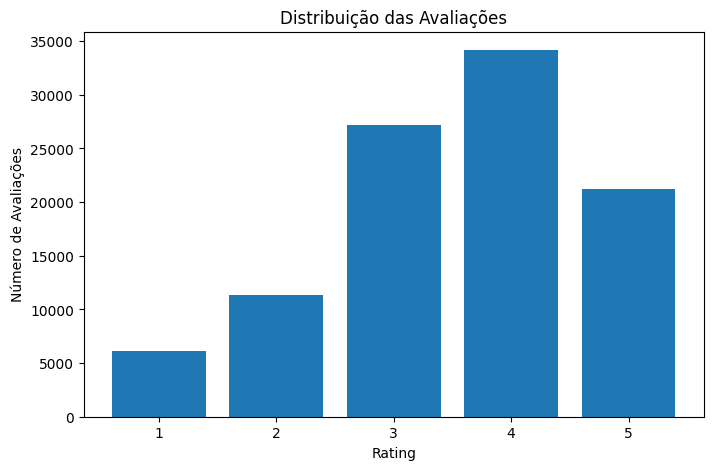

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    rating_distribution["rating"],
    rating_distribution["count"]
)

plt.title("Distribuição das Avaliações")
plt.xlabel("Rating")
plt.ylabel("Número de Avaliações")
plt.xticks([1, 2, 3, 4, 5])

plt.show()

### 4.2 Estatísticas das Avaliações

Além da distribuição das frequências, algumas medidas descritivas ajudam a compreender o comportamento geral das avaliações.

Serão analisadas medidas de tendência central e dispersão, como média, mediana e desvio padrão.

In [32]:
ratings["rating"].describe()

,rating
count,100000.000000
mean,3.529860
std,1.125674
min,1.000000
25%,3.000000
50%,4.000000
75%,4.000000
max,5.000000


In [34]:
print(f"Média:         {ratings['rating'].mean():.2f}")
print(f"Mediana:       {ratings['rating'].median():.2f}")
print(f"Desvio padrão: {ratings['rating'].std():.2f}")

positive = (ratings["rating"] >= 4).mean() * 100
neutral = (ratings["rating"] == 3).mean() * 100
negative = (ratings["rating"] <= 2).mean() * 100

print(f"Positivas (4-5): {positive:.2f}%")
print(f"Neutras (3):     {neutral:.2f}%")
print(f"Negativas (1-2): {negative:.2f}%")

Média:         3.53
Mediana:       4.00
Desvio padrão: 1.13
Positivas (4-5): 55.38%
Neutras (3):     27.15%
Negativas (1-2): 17.48%


### 4.3 Distribuição das Avaliações ao Longo do Tempo

Cada avaliação do MovieLens possui um timestamp indicando quando a interação ocorreu.

A dimensão temporal é particularmente importante em sistemas de recomendação, pois as preferências dos usuários podem mudar ao longo do tempo e, em um cenário real, o sistema somente pode utilizar informações disponíveis até o momento da recomendação.

Inicialmente, será analisada a distribuição geral das avaliações ao longo do período coberto pelo dataset.

In [35]:
print("Primeira avaliação:", ratings["datetime"].min())
print("Última avaliação:  ", ratings["datetime"].max())

Primeira avaliação: 1997-09-20 03:05:10
Última avaliação:   1998-04-22 23:10:38


In [36]:
ratings_by_month = (
    ratings
    .set_index("datetime")
    .resample("ME")
    .size()
)

ratings_by_month.head()

,0
datetime,
1997-09-30,6704
1997-10-31,10304
1997-11-30,23980
1997-12-31,11911
1998-01-31,14095


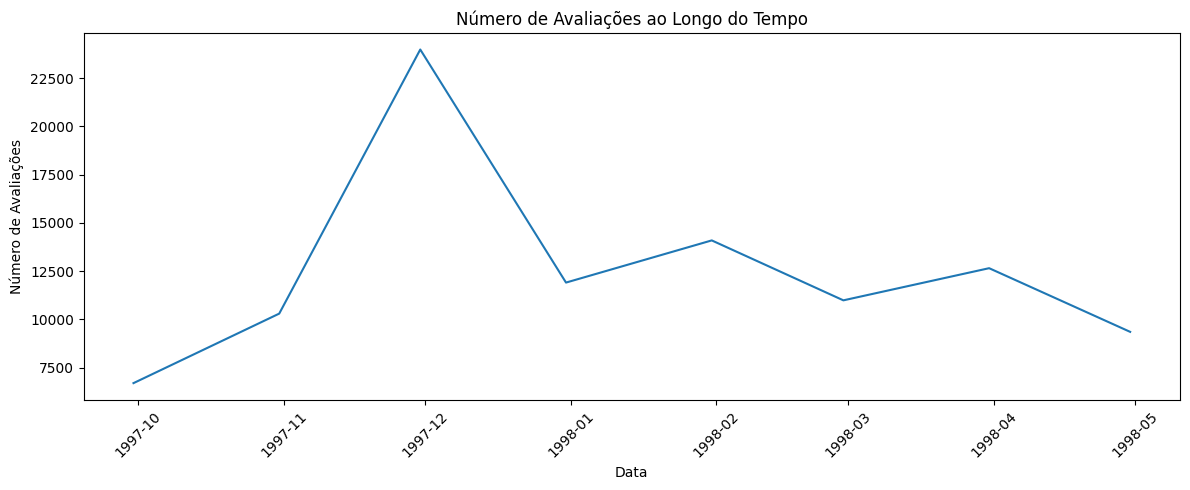

In [37]:
plt.figure(figsize=(12, 5))

plt.plot(
    ratings_by_month.index,
    ratings_by_month.values
)

plt.title("Número de Avaliações ao Longo do Tempo")
plt.xlabel("Data")
plt.ylabel("Número de Avaliações")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### 4.4 Distribuição por dia da semana

In [38]:
ratings["day_of_week"] = ratings["datetime"].dt.day_name()

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

ratings_by_day = (
    ratings["day_of_week"]
    .value_counts()
    .reindex(day_order)
)

ratings_by_day

,count
day_of_week,
Monday,13174
Tuesday,13933
Wednesday,16621
Thursday,13364
Friday,15918
Saturday,15077
Sunday,11913


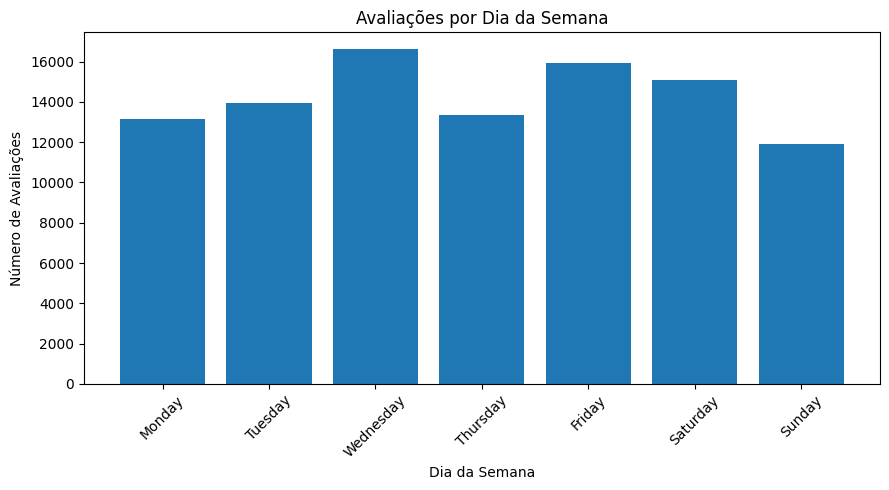

In [39]:
plt.figure(figsize=(9, 5))

plt.bar(
    ratings_by_day.index,
    ratings_by_day.values
)

plt.title("Avaliações por Dia da Semana")
plt.xlabel("Dia da Semana")
plt.ylabel("Número de Avaliações")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### 4.5 Principais Observações

A análise das avaliações permite identificar algumas características importantes do conjunto de dados:

- as avaliações não estão uniformemente distribuídas entre os valores de 1 a 5;
- existe maior concentração de avaliações nos valores intermediários e altos;
- ratings 4 e 5 representam um sinal explícito mais forte de preferência do usuário;
- o volume de interações varia ao longo do período observado;
- a presença do timestamp permite considerar estratégias de avaliação que respeitem a ordem temporal das interações.

Essas características serão relevantes posteriormente tanto para a definição do sinal de preferência quanto para a escolha das métricas de avaliação dos modelos.

## 5. Análise dos Usuários

### 5.1 Número de Avaliações por Usuário

A quantidade de interações disponíveis para cada usuário é uma característica importante em sistemas de recomendação.

Usuários com um histórico maior fornecem mais informações sobre suas preferências, enquanto usuários com poucas interações representam um desafio maior para abordagens baseadas em Collaborative Filtering.

Inicialmente, será calculado o número de avaliações realizadas por cada usuário.

In [40]:
user_activity = (
    ratings
    .groupby("user_id")
    .size()
    .rename("n_ratings")
    .sort_values(ascending=False)
)

user_activity.head(10)

,n_ratings
user_id,
405,737
655,685
13,636
450,540
276,518
416,493
537,490
303,484
234,480


In [41]:
user_activity.describe()

,n_ratings
count,943.000000
mean,106.044539
std,100.931743
min,20.000000
25%,33.000000
50%,65.000000
75%,148.000000
max,737.000000


In [42]:
print(f"Menor número de avaliações:  {user_activity.min()}")
print(f"Maior número de avaliações:  {user_activity.max()}")
print(f"Média:                       {user_activity.mean():.2f}")
print(f"Mediana:                     {user_activity.median():.2f}")

Menor número de avaliações:  20
Maior número de avaliações:  737
Média:                       106.04
Mediana:                     65.00


### 5.2 Distribuição da Atividade dos Usuários

Embora a média de avaliações por usuário forneça uma visão geral do dataset, ela não mostra como essas interações estão distribuídas.

Em sistemas de recomendação é comum encontrar usuários com níveis de atividade muito diferentes. Por isso, será analisada a distribuição da quantidade de avaliações realizadas por usuário.

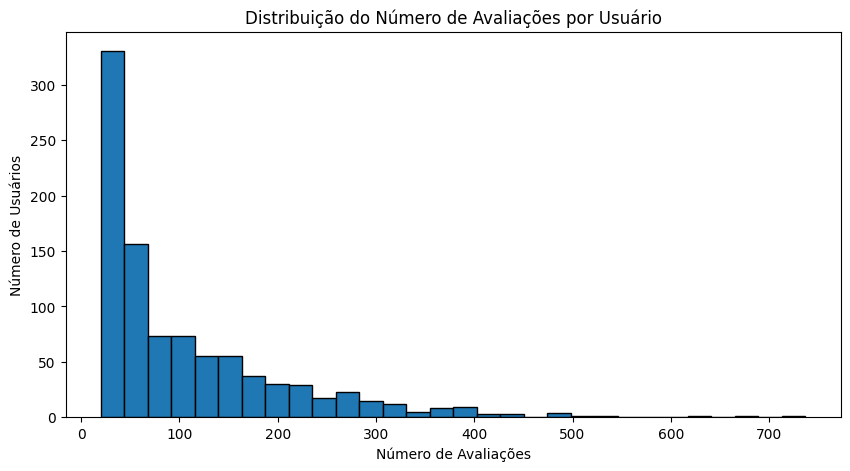

In [43]:
plt.figure(figsize=(10, 5))

plt.hist(
    user_activity,
    bins=30,
    edgecolor="black"
)

plt.title("Distribuição do Número de Avaliações por Usuário")
plt.xlabel("Número de Avaliações")
plt.ylabel("Número de Usuários")

plt.show()

### 5.3 Comportamento de Avaliação dos Usuários

Além da quantidade de interações, usuários podem apresentar diferentes padrões na forma como atribuem avaliações.

Alguns usuários podem utilizar predominantemente ratings altos, enquanto outros podem ser mais críticos. Essas diferenças são relevantes porque o mesmo valor de rating pode possuir significados ligeiramente diferentes dependendo do comportamento individual do usuário.

Nesta etapa serão analisadas a média e a dispersão das avaliações de cada usuário.

In [44]:
user_stats = (
    ratings
    .groupby("user_id")
    .agg(
        n_ratings=("rating", "size"),
        mean_rating=("rating", "mean"),
        std_rating=("rating", "std")
    )
)

user_stats.head()

,n_ratings,mean_rating,std_rating
user_id,,,
1,272,3.610294,1.263585
2,62,3.709677,1.030472
3,54,2.796296,1.219026
4,24,4.333333,0.916831
5,175,2.874286,1.362963


In [45]:
user_stats.describe()

,n_ratings,mean_rating,std_rating
count,943.000000,943.000000,943.000000
mean,106.044539,3.588191,1.019883
std,100.931743,0.445233,0.205150
min,20.000000,1.491954,0.344350
25%,33.000000,3.323054,0.875950
50%,65.000000,3.620690,1.012007
75%,148.000000,3.869565,1.139879
max,737.000000,4.869565,1.749906


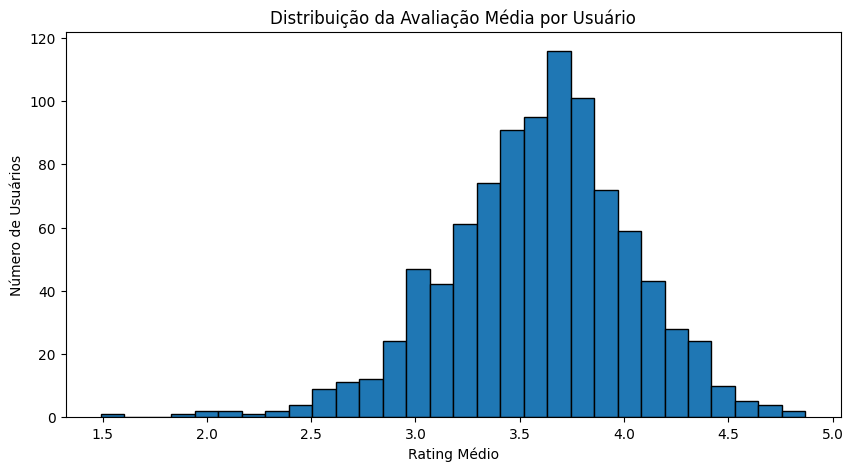

In [46]:
plt.figure(figsize=(10, 5))

plt.hist(
    user_stats["mean_rating"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribuição da Avaliação Média por Usuário")
plt.xlabel("Rating Médio")
plt.ylabel("Número de Usuários")

plt.show()

### 5.4 Relação entre Atividade e Avaliação

Para investigar possíveis diferenças de comportamento entre usuários mais e menos ativos, será analisada a relação entre o número de avaliações realizadas e a média dos ratings atribuídos.

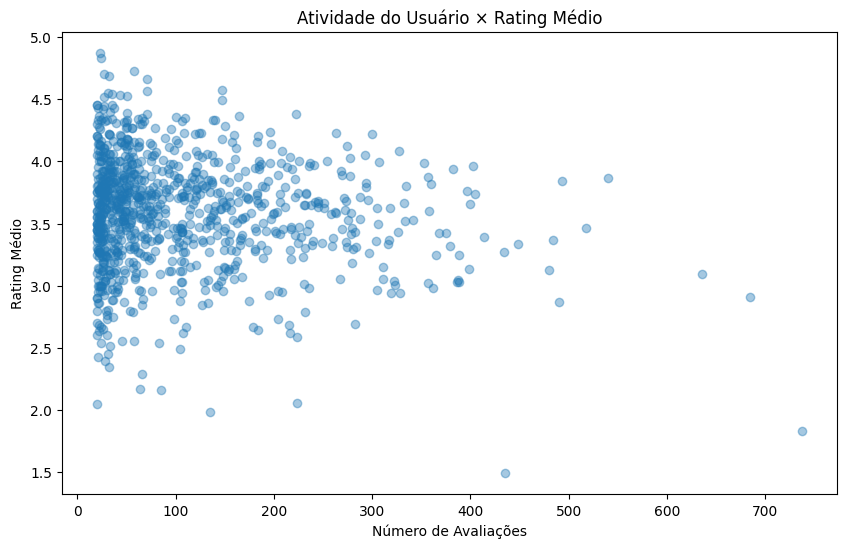

In [47]:
plt.figure(figsize=(10, 6))

plt.scatter(
    user_stats["n_ratings"],
    user_stats["mean_rating"],
    alpha=0.4
)

plt.title("Atividade do Usuário × Rating Médio")
plt.xlabel("Número de Avaliações")
plt.ylabel("Rating Médio")

plt.show()

In [48]:
correlation = user_stats[
    ["n_ratings", "mean_rating"]
].corr()

correlation

,n_ratings,mean_rating
n_ratings,1.000000,-0.137795
mean_rating,-0.137795,1.000000


### 5.5 Implicações para Collaborative Filtering

A análise mostra que os usuários podem apresentar diferentes padrões na utilização da escala de ratings.

Um rating 4, por exemplo, pode representar uma avaliação relativamente comum para um usuário que possui média 4,2, mas uma avaliação bastante positiva para outro usuário cuja média histórica é 2,8.

Essa característica sugere que modelos de Collaborative Filtering podem se beneficiar de técnicas de normalização ou centralização das avaliações por usuário.

Além disso, a quantidade desigual de interações significa que a quantidade de informação disponível para representar cada usuário também varia.

### 5.6 Principais Observações

A análise dos usuários evidencia algumas características relevantes para a construção dos modelos de recomendação:

- a quantidade de avaliações varia consideravelmente entre os usuários;
- o MovieLens 100K possui um mínimo de 20 avaliações por usuário, reduzindo artificialmente o problema de usuários com pouco ou nenhum histórico;
- alguns usuários são significativamente mais ativos do que outros;
- existem diferenças no padrão individual de utilização da escala de ratings;
- o rating médio de cada usuário pode refletir tanto sua preferência pelos filmes quanto sua forma particular de utilizar a escala de avaliação;
- essas diferenças podem justificar técnicas de centralização ou normalização dos ratings em modelos de Collaborative Filtering.

Essas características deverão ser consideradas na construção e avaliação dos modelos.

## 6. Análise dos Filmes

### 6.1 Número de Avaliações por Filme

A quantidade de avaliações recebidas por um filme pode ser utilizada como uma medida simples de sua popularidade dentro do dataset.

Em sistemas de recomendação, essa distribuição é particularmente relevante porque itens populares possuem mais informações disponíveis para o aprendizado dos modelos, enquanto itens com poucas interações tendem a ser mais difíceis de recomendar por abordagens baseadas em Collaborative Filtering.

In [49]:
movie_activity = (
    ratings
    .groupby("item_id")
    .size()
    .rename("n_ratings")
    .sort_values(ascending=False)
)

movie_activity.head(10)

,n_ratings
item_id,
50,583
258,509
100,508
181,507
294,485
286,481
288,478
1,452
300,431


In [50]:
movie_activity.describe()

,n_ratings
count,1682.000000
mean,59.453032
std,80.383846
min,1.000000
25%,6.000000
50%,27.000000
75%,80.000000
max,583.000000


In [51]:
print(f"Menor número de avaliações: {movie_activity.min()}")
print(f"Maior número de avaliações: {movie_activity.max()}")
print(f"Média:                      {movie_activity.mean():.2f}")
print(f"Mediana:                    {movie_activity.median():.2f}")

Menor número de avaliações: 1
Maior número de avaliações: 583
Média:                      59.45
Mediana:                    27.00


### 6.2 Distribuição da Popularidade

A média de avaliações por filme não representa necessariamente a distribuição real das interações.

É comum em sistemas de recomendação que poucos itens concentrem grande quantidade de interações, enquanto muitos itens possuam um histórico significativamente menor.

A seguir será analisada a distribuição do número de avaliações recebidas pelos filmes.

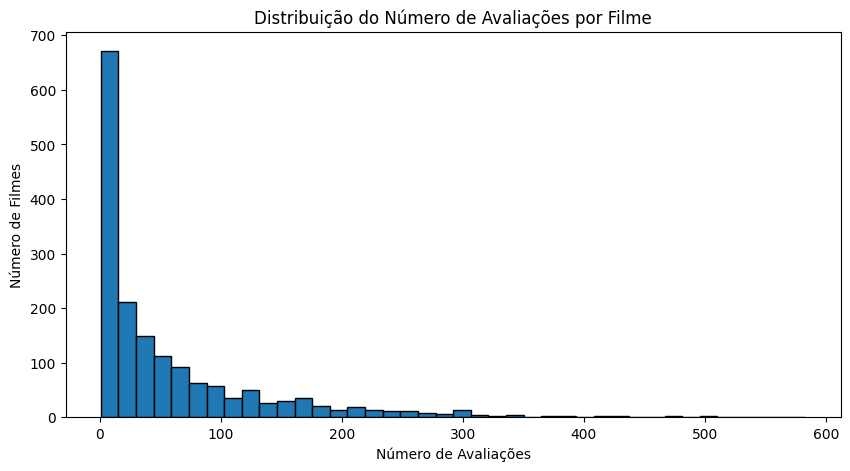

In [52]:
plt.figure(figsize=(10, 5))

plt.hist(
    movie_activity,
    bins=40,
    edgecolor="black"
)

plt.title("Distribuição do Número de Avaliações por Filme")
plt.xlabel("Número de Avaliações")
plt.ylabel("Número de Filmes")

plt.show()

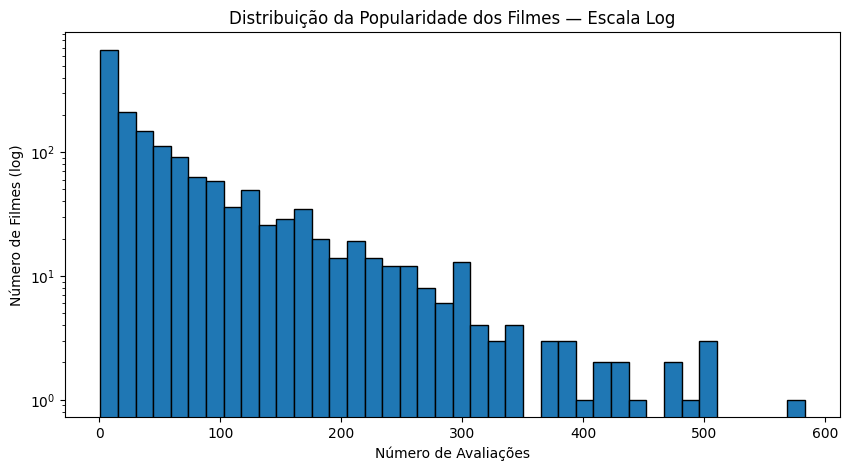

In [53]:
plt.figure(figsize=(10, 5))

plt.hist(
    movie_activity,
    bins=40,
    edgecolor="black"
)

plt.yscale("log")

plt.title("Distribuição da Popularidade dos Filmes — Escala Log")
plt.xlabel("Número de Avaliações")
plt.ylabel("Número de Filmes (log)")

plt.show()

### 6.3 Filmes Mais Populares

A popularidade de um item pode ser representada de maneira simples pelo número de interações recebidas.

Os filmes com maior número de avaliações são apresentados a seguir.

In [56]:
movie_stats = (
    ratings
    .groupby("item_id")
    .agg(
        n_ratings=("rating", "size"),
        mean_rating=("rating", "mean")
    )
    .reset_index()
)

movie_stats = movie_stats.merge(
    movies[["item_id", "title"]],
    on="item_id",
    how="left"
)

most_popular = (
    movie_stats
    .sort_values("n_ratings", ascending=False)
    [["title", "n_ratings", "mean_rating"]]
    .head(10)
)

most_popular


,title,n_ratings,mean_rating
49,Star Wars (1977),583,4.358491
257,Contact (1997),509,3.803536
99,Fargo (1996),508,4.155512
180,Return of the Jedi (1983),507,4.007890
293,Liar Liar (1997),485,3.156701
285,"English Patient, The (1996)",481,3.656965
287,Scream (1996),478,3.441423
0,Toy Story (1995),452,3.878319
299,Air Force One (1997),431,3.631090
120,Independence Day (ID4) (1996),429,3.438228


### 6.4 Filmes Mais Bem Avaliados

O rating médio pode ser utilizado como uma medida simples da avaliação recebida por um filme. Entretanto, essa métrica deve ser interpretada em conjunto com o número de avaliações.

Filmes com poucas interações podem apresentar médias extremas sem que exista evidência suficiente de que essas médias sejam representativas.

In [58]:
highest_rated = (
    movie_stats
    .sort_values(
        ["mean_rating", "n_ratings"],
        ascending=[False, False]
    )
    [["title", "mean_rating", "n_ratings"]]
    .head(10)
)

highest_rated

,title,mean_rating,n_ratings
1188,Prefontaine (1997),5.0,3
1292,Star Kid (1997),5.0,3
1466,"Saint of Fort Washington, The (1993)",5.0,2
1499,Santa with Muscles (1996),5.0,2
813,"Great Day in Harlem, A (1994)",5.0,1
1121,They Made Me a Criminal (1939),5.0,1
1200,Marlene Dietrich: Shadow and Light (1996),5.0,1
1535,Aiqing wansui (1994),5.0,1
1598,Someone Else's America (1995),5.0,1
1652,Entertaining Angels: The Dorothy Day Story (1996),5.0,1


Para reduzir a influência de médias calculadas sobre amostras muito pequenas, foi utilizado um limite mínimo de 50 avaliações.

Esse valor é utilizado apenas como critério exploratório e não representa um hiperparâmetro otimizado.

In [59]:
min_ratings = 50

highest_rated_reliable = (
    movie_stats[
        movie_stats["n_ratings"] >= min_ratings
    ]
    .sort_values("mean_rating", ascending=False)
    [["title", "mean_rating", "n_ratings"]]
    .head(10)
)

highest_rated_reliable

,title,mean_rating,n_ratings
407,"Close Shave, A (1995)",4.491071,112
317,Schindler's List (1993),4.466443,298
168,"Wrong Trousers, The (1993)",4.466102,118
482,Casablanca (1942),4.456790,243
113,Wallace & Gromit: The Best of Aardman Animatio...,4.447761,67
63,"Shawshank Redemption, The (1994)",4.445230,283
602,Rear Window (1954),4.387560,209
11,"Usual Suspects, The (1995)",4.385768,267
49,Star Wars (1977),4.358491,583
177,12 Angry Men (1957),4.344000,125


### 6.5 Relação entre Popularidade e Avaliação

Popularidade e preferência representam conceitos diferentes.

Um filme pode receber muitas avaliações sem necessariamente possuir um rating médio elevado. Para investigar essa relação, será comparado o número de avaliações recebidas com o rating médio dos filmes.

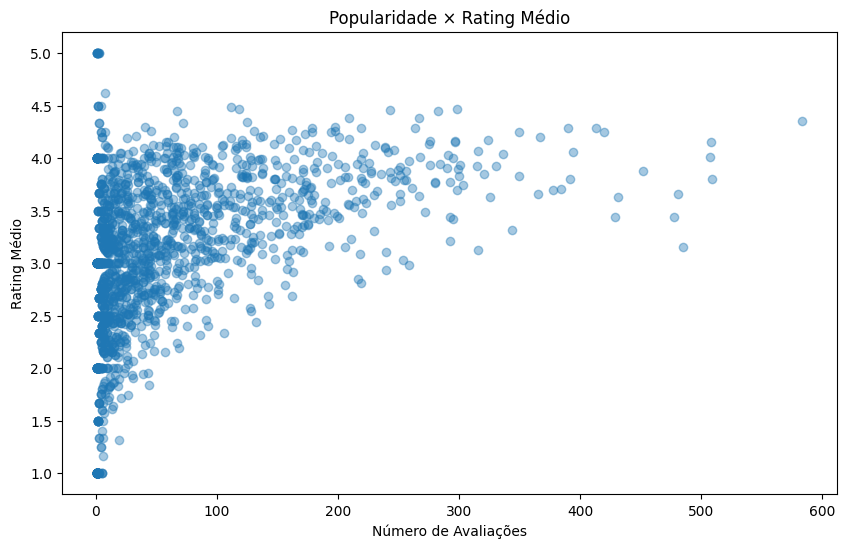

In [60]:
plt.figure(figsize=(10, 6))

plt.scatter(
    movie_stats["n_ratings"],
    movie_stats["mean_rating"],
    alpha=0.4
)

plt.title("Popularidade × Rating Médio")
plt.xlabel("Número de Avaliações")
plt.ylabel("Rating Médio")

plt.show()

In [61]:
movie_stats[
    ["n_ratings", "mean_rating"]
].corr()

,n_ratings,mean_rating
n_ratings,1.000000,0.429659
mean_rating,0.429659,1.000000


### 6.6 Long Tail

Em muitos sistemas de recomendação, a distribuição das interações entre os itens apresenta o fenômeno conhecido como **long tail**.

Poucos itens concentram uma grande parcela das interações, enquanto muitos itens recebem relativamente poucas avaliações.

Esse comportamento pode influenciar diretamente os modelos de recomendação, favorecendo itens populares e dificultando a descoberta de itens menos conhecidos.

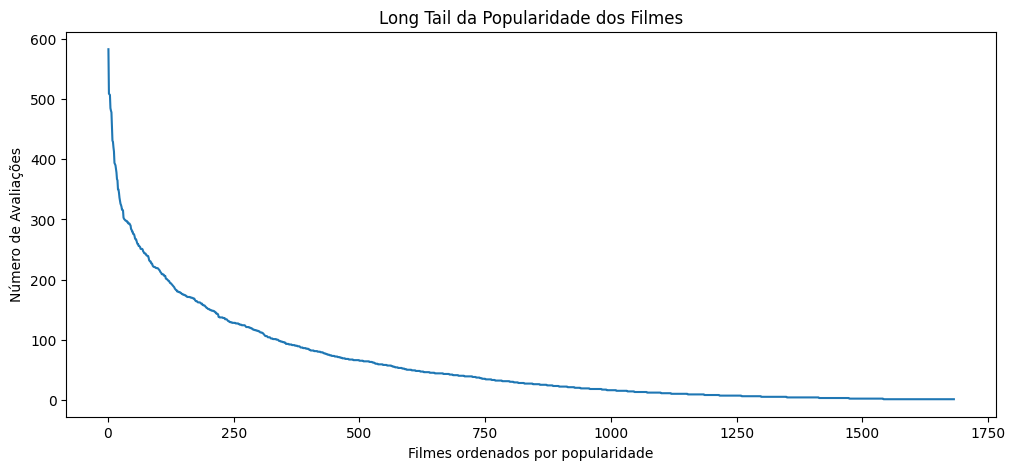

In [62]:
popularity = (
    movie_activity
    .sort_values(ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(12, 5))

plt.plot(
    range(1, len(popularity) + 1),
    popularity.values
)

plt.title("Long Tail da Popularidade dos Filmes")
plt.xlabel("Filmes ordenados por popularidade")
plt.ylabel("Número de Avaliações")

plt.show()

In [63]:
popularity_df = (
    movie_activity
    .sort_values(ascending=False)
    .rename("n_ratings")
    .reset_index()
)

popularity_df["cumulative_ratings"] = (
    popularity_df["n_ratings"].cumsum()
)

popularity_df["cumulative_percentage"] = (
    popularity_df["cumulative_ratings"]
    / popularity_df["n_ratings"].sum()
)

n_movies_80 = (
    popularity_df["cumulative_percentage"] < 0.80
).sum() + 1

percentage_movies_80 = (
    n_movies_80 / len(popularity_df) * 100
)

print(
    f"{n_movies_80} filmes "
    f"({percentage_movies_80:.2f}% do catálogo) "
    f"concentram aproximadamente 80% das avaliações."
)

536 filmes (31.87% do catálogo) concentram aproximadamente 80% das avaliações.


### 6.7 Curva acumulada de popularidade

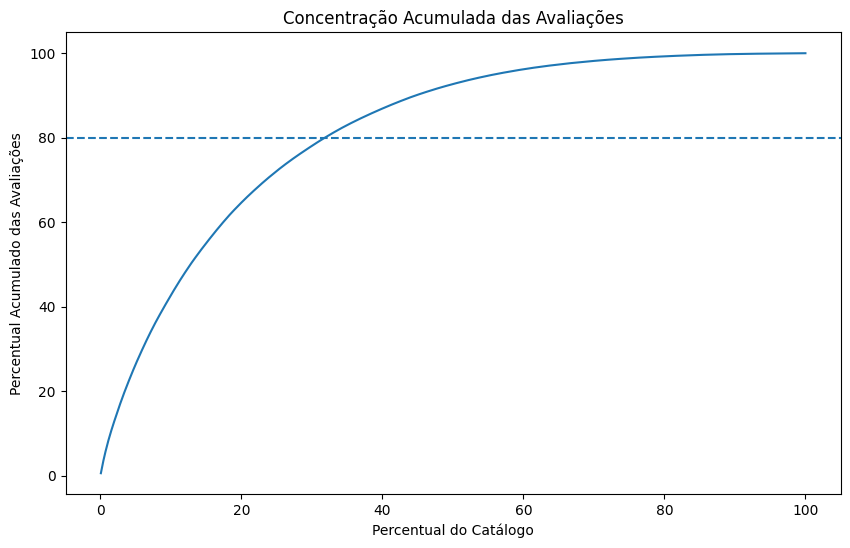

In [64]:
popularity_df["catalog_percentage"] = (
    (popularity_df.index + 1)
    / len(popularity_df)
    * 100
)

plt.figure(figsize=(10, 6))

plt.plot(
    popularity_df["catalog_percentage"],
    popularity_df["cumulative_percentage"] * 100
)

plt.axhline(
    y=80,
    linestyle="--"
)

plt.title("Concentração Acumulada das Avaliações")
plt.xlabel("Percentual do Catálogo")
plt.ylabel("Percentual Acumulado das Avaliações")

plt.show()

### 6.8 Principais Observações

A análise dos filmes evidencia características importantes do conjunto de dados:

- a quantidade de avaliações é distribuída de maneira desigual entre os filmes;
- poucos filmes concentram um volume elevado de interações, enquanto muitos itens possuem poucas avaliações;
- o rating médio isoladamente não é suficiente para identificar os filmes mais relevantes, pois médias extremas podem ser resultado de poucas observações;
- popularidade e qualidade percebida representam sinais distintos;
- a distribuição das interações apresenta comportamento de **long tail**;
- itens populares possuem maior quantidade de informação disponível para modelos baseados em Collaborative Filtering;
- itens localizados na cauda possuem menos informação colaborativa e, consequentemente, tendem a ser mais difíceis de recomendar.

Essas características sugerem que a avaliação dos futuros modelos não deve considerar apenas precisão preditiva, mas também aspectos como cobertura, diversidade e viés de popularidade.

### 7.1 Distribuição dos Gêneros

Os gêneros representam as principais características de conteúdo disponíveis para os filmes no MovieLens 100K.

Cada filme pode pertencer a um ou mais gêneros simultaneamente, representados no dataset por variáveis binárias.

Inicialmente, será analisada a distribuição dos filmes entre os diferentes gêneros.

In [67]:
genre_counts = (
    movies[genres]
    .sum()
    .sort_values(ascending=False)
)

genre_counts

,0
Drama,725
Comedy,505
Action,251
Thriller,251
Romance,247
Adventure,135
Children,122
Crime,109
Sci-Fi,101
Horror,92


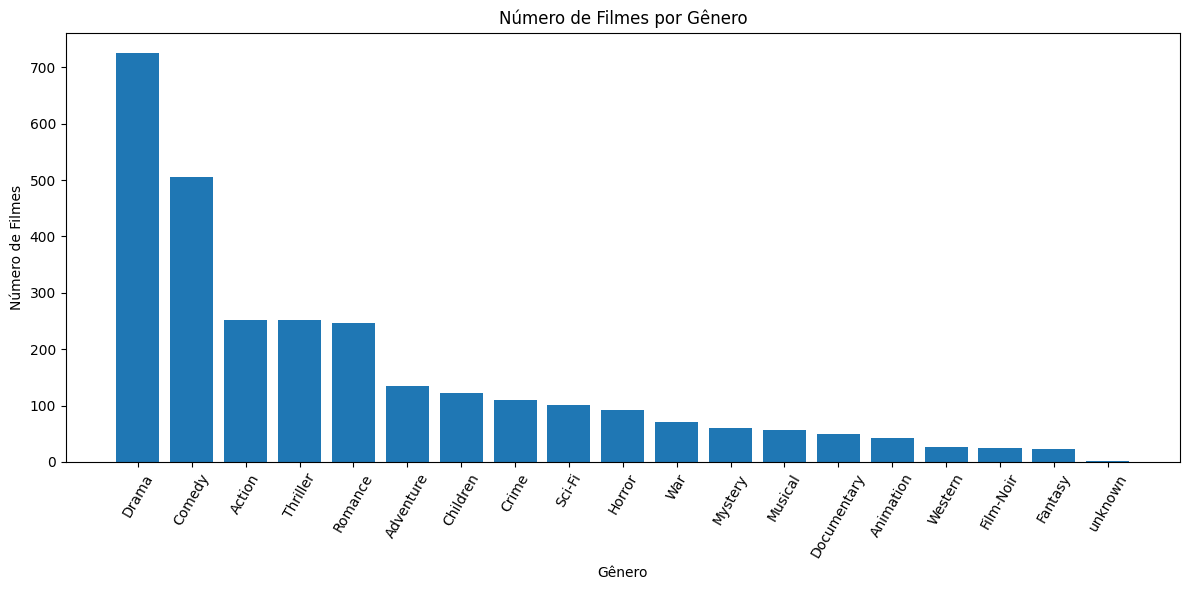

In [68]:
plt.figure(figsize=(12, 6))

plt.bar(
    genre_counts.index,
    genre_counts.values
)

plt.title("Número de Filmes por Gênero")
plt.xlabel("Gênero")
plt.ylabel("Número de Filmes")

plt.xticks(rotation=60)
plt.tight_layout()

plt.show()

In [71]:
movies["n_genres"] = movies[genres].sum(axis=1)
movies["n_genres"].describe()

,n_genres
count,1682.000000
mean,1.719976
std,0.868207
min,1.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,6.000000


In [72]:
movies["n_genres"].value_counts().sort_index()

,count
n_genres,
1,833
2,569
3,215
4,51
5,11
6,3


### 7.2 Popularidade por Gênero

Além da quantidade de filmes disponíveis em cada gênero, é possível analisar o volume de interações associado a cada categoria.

Como um filme pode possuir múltiplos gêneros, uma mesma avaliação pode contribuir para mais de uma categoria. Portanto, os valores apresentados não representam grupos mutuamente exclusivos.

O número de avaliações por gênero fornece uma medida aproximada da presença de cada categoria no histórico de interações dos usuários.

In [73]:
ratings_movies = ratings.merge(
    movies[
        ["item_id", "title"] + genres
    ],
    on="item_id",
    how="left"
)

genre_popularity = {}

for genre in genres:
    genre_popularity[genre] = ratings_movies.loc[
        ratings_movies[genre] == 1
    ].shape[0]

genre_popularity = (
    pd.Series(genre_popularity)
    .sort_values(ascending=False)
)

genre_popularity

,0
Drama,39895
Comedy,29832
Action,25589
Thriller,21872
Romance,19461
Adventure,13753
Sci-Fi,12730
War,9398
Crime,8055
Children,7182


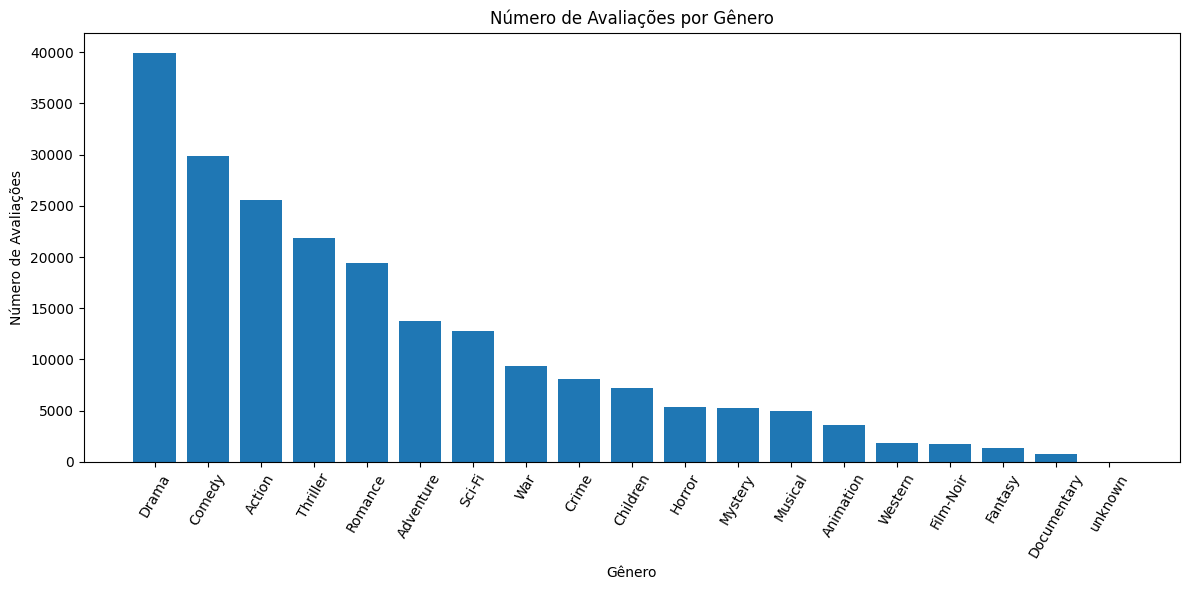

In [74]:
plt.figure(figsize=(12, 6))

plt.bar(
    genre_popularity.index,
    genre_popularity.values
)

plt.title("Número de Avaliações por Gênero")
plt.xlabel("Gênero")
plt.ylabel("Número de Avaliações")

plt.xticks(rotation=60)
plt.tight_layout()

plt.show()

### 7.3 Avaliação Média por Gênero

O volume de avaliações indica a presença de cada gênero nas interações, mas não necessariamente o nível de preferência dos usuários.

Para complementar a análise, será calculado o rating médio associado aos filmes de cada gênero.

Assim como na análise anterior, filmes com múltiplos gêneros contribuem para as estatísticas de todas as categorias às quais pertencem.

In [75]:
genre_stats = []

for genre in genres:
    genre_ratings = ratings_movies.loc[
        ratings_movies[genre] == 1,
        "rating"
    ]

    genre_stats.append({
        "genre": genre,
        "n_ratings": len(genre_ratings),
        "mean_rating": genre_ratings.mean()
    })

genre_stats = pd.DataFrame(genre_stats)

genre_stats = genre_stats.sort_values(
    "mean_rating",
    ascending=False
)

genre_stats

,genre,n_ratings,mean_rating
10,Film-Noir,1733,3.921523
17,War,9398,3.815812
8,Drama,39895,3.687379
7,Documentary,758,3.672823
13,Mystery,5245,3.638132
6,Crime,8055,3.632278
14,Romance,19461,3.621705
18,Western,1854,3.613269
3,Animation,3605,3.576699
15,Sci-Fi,12730,3.560723


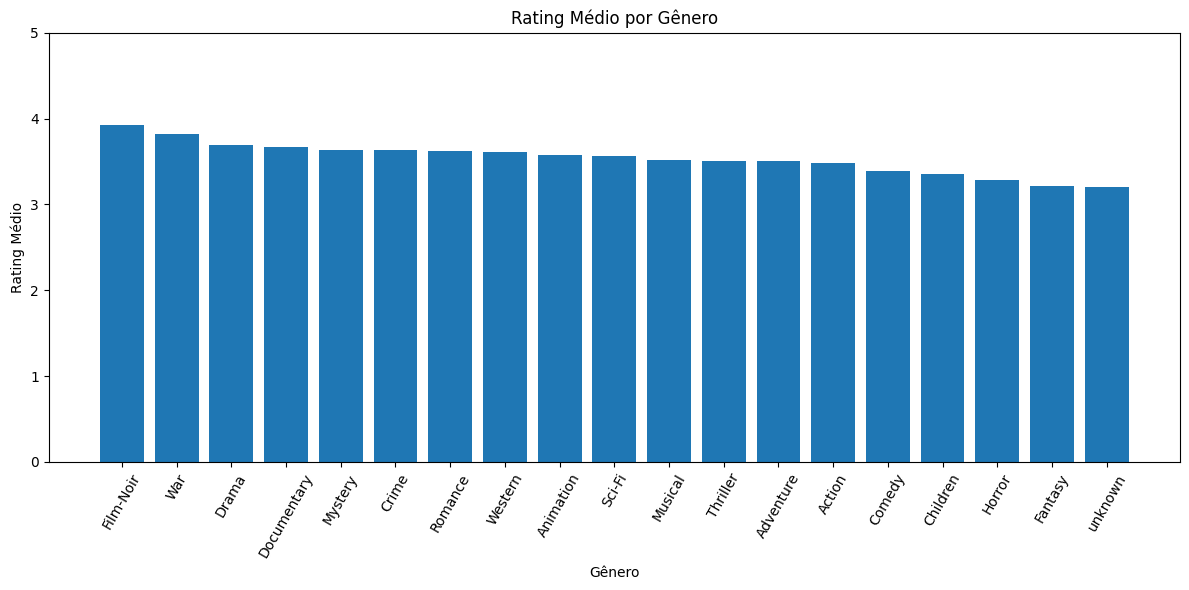

In [76]:
plt.figure(figsize=(12, 6))

plt.bar(
    genre_stats["genre"],
    genre_stats["mean_rating"]
)

plt.title("Rating Médio por Gênero")
plt.xlabel("Gênero")
plt.ylabel("Rating Médio")

plt.xticks(rotation=60)
plt.ylim(0, 5)
plt.tight_layout()

plt.show()

### 7.4 Preferências dos Usuários por Gênero

As análises anteriores consideram o comportamento agregado do conjunto de usuários. Entretanto, sistemas de recomendação personalizados precisam identificar diferenças entre preferências individuais.

Como aproximação inicial, serão consideradas avaliações iguais ou superiores a 4 como sinais positivos de preferência.

A partir dessas interações, será possível construir um perfil simples de preferência por gênero para cada usuário.

In [79]:
positive_ratings = ratings_movies[
    ratings_movies["rating"] >= 4
].copy()

user_genre_preferences = (
    positive_ratings
    .groupby("user_id")[genres]
    .sum()
)

user_genre_preferences.head()

,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
user_id,,,,,,,,,,,,,,,,,,,
1,1,39,17,5,5,49,15,5,78,1,1,7,6,3,30,32,30,15,3
2,0,7,3,1,2,12,6,0,23,0,2,0,0,1,13,2,6,2,0
3,0,3,2,0,0,3,4,1,8,0,0,0,0,4,2,2,5,2,0
4,0,5,2,0,0,4,4,1,5,0,0,1,1,3,2,4,7,2,0
5,1,23,14,8,5,33,7,0,7,1,1,8,4,1,6,19,5,7,1


In [81]:
#Normalizando o perfil
user_genre_profile = (
    user_genre_preferences
    .div(
        user_genre_preferences.sum(axis=1),
        axis=0
    )
)

user_genre_profile.head()

,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
user_id,,,,,,,,,,,,,,,,,,,
1,0.002924,0.114035,0.049708,0.01462,0.014620,0.143275,0.043860,0.014620,0.228070,0.002924,0.002924,0.020468,0.017544,0.008772,0.087719,0.093567,0.087719,0.043860,0.008772
2,0.000000,0.087500,0.037500,0.01250,0.025000,0.150000,0.075000,0.000000,0.287500,0.000000,0.025000,0.000000,0.000000,0.012500,0.162500,0.025000,0.075000,0.025000,0.000000
3,0.000000,0.083333,0.055556,0.00000,0.000000,0.083333,0.111111,0.027778,0.222222,0.000000,0.000000,0.000000,0.000000,0.111111,0.055556,0.055556,0.138889,0.055556,0.000000
4,0.000000,0.121951,0.048780,0.00000,0.000000,0.097561,0.097561,0.024390,0.121951,0.000000,0.000000,0.024390,0.024390,0.073171,0.048780,0.097561,0.170732,0.048780,0.000000
5,0.006623,0.152318,0.092715,0.05298,0.033113,0.218543,0.046358,0.000000,0.046358,0.006623,0.006623,0.052980,0.026490,0.006623,0.039735,0.125828,0.033113,0.046358,0.006623


In [83]:
#Visualizando um usuário

user_id = 1

profile = (
    user_genre_profile
    .loc[user_id]
    .sort_values(ascending=False)
)

profile

,1
Drama,0.228070
Comedy,0.143275
Action,0.114035
Sci-Fi,0.093567
Romance,0.087719
Thriller,0.087719
Adventure,0.049708
Crime,0.043860
War,0.043860
Horror,0.020468


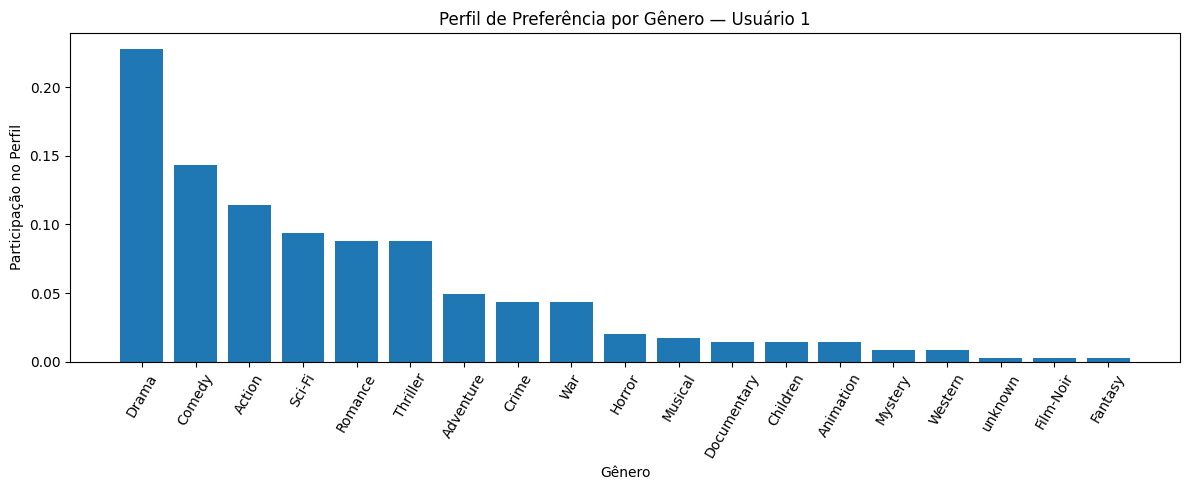

In [84]:
plt.figure(figsize=(12, 5))

plt.bar(
    profile.index,
    profile.values
)

plt.title(f"Perfil de Preferência por Gênero — Usuário {user_id}")
plt.xlabel("Gênero")
plt.ylabel("Participação no Perfil")

plt.xticks(rotation=60)
plt.tight_layout()

plt.show()

### 7.5 Implicações para Content-Based Filtering

Os gêneros fornecem uma representação simples do conteúdo dos filmes.

Cada filme pode ser representado por um vetor binário indicando os gêneros aos quais pertence. De maneira semelhante, o histórico de interações positivas pode ser utilizado para construir um vetor representando as preferências de cada usuário.

Essa representação permite comparar o perfil do usuário com as características dos filmes, formando a base de uma abordagem simples de **Content-Based Filtering**.

### 7.6 Principais Observações

A análise dos gêneros permite identificar características relevantes para futuras abordagens baseadas em conteúdo:

- os gêneros não estão distribuídos uniformemente entre os filmes;
- um mesmo filme pode pertencer simultaneamente a múltiplos gêneros;
- alguns gêneros concentram uma parcela maior das interações;
- popularidade e rating médio apresentam comportamentos distintos entre os gêneros;
- usuários apresentam diferentes padrões de interação positiva com cada gênero;
- o histórico de avaliações positivas pode ser utilizado para construir uma representação vetorial simples das preferências de cada usuário;
- os gêneros fornecem, portanto, uma primeira fonte de informação para modelos de **Content-Based Filtering**.

## 8. Matriz Usuário × Item

### 8.1 Construção da Matriz

Uma representação tradicional em sistemas de recomendação é a **matriz usuário-item**, na qual:

- cada linha representa um usuário;
- cada coluna representa um item;
- cada célula contém a avaliação atribuída pelo usuário ao item.

Quando um usuário não avaliou determinado filme, a célula correspondente não possui uma interação observada.

Essa representação permite visualizar o problema de recomendação como uma matriz parcialmente preenchida, na qual os modelos procuram identificar padrões capazes de estimar preferências para itens ainda não avaliados.

In [85]:
user_item_matrix = ratings.pivot(
    index="user_id",
    columns="item_id",
    values="rating"
)

user_item_matrix.head()

item_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [86]:
n_users_matrix, n_items_matrix = user_item_matrix.shape

print(f"Usuários: {n_users_matrix:,}")
print(f"Filmes:   {n_items_matrix:,}")
print(f"Células:  {user_item_matrix.size:,}")

Usuários: 943
Filmes:   1,682
Células:  1,586,126


### 8.2 Densidade e Esparsidade

Em sistemas de recomendação, a matriz usuário-item normalmente contém uma quantidade muito maior de interações possíveis do que de interações efetivamente observadas.

A **densidade** representa a proporção de células da matriz para as quais existe uma interação.

A **esparsidade**, por sua vez, representa a proporção de combinações usuário-item sem interação observada.

In [87]:
n_possible_interactions = (
    n_users_matrix * n_items_matrix
)

n_observed_interactions = (
    user_item_matrix.notna().sum().sum()
)

density = (
    n_observed_interactions
    / n_possible_interactions
)

sparsity = 1 - density

print(f"Interações possíveis:   {n_possible_interactions:,}")
print(f"Interações observadas:  {n_observed_interactions:,}")
print(f"Densidade:              {density:.2%}")
print(f"Esparsidade:            {sparsity:.2%}")

Interações possíveis:   1,586,126
Interações observadas:  100,000
Densidade:              6.30%
Esparsidade:            93.70%


Aproximadamente **93,7% das combinações possíveis entre usuários e filmes não possuem uma avaliação observada**.

Essa elevada esparsidade é uma característica típica de problemas de recomendação e representa um dos principais desafios para métodos baseados em Collaborative Filtering.

### 8.3 Visualização das Interações

Para visualizar a estrutura esparsa da matriz, será considerada uma amostra de usuários e filmes.

Nesta representação, o objetivo não é analisar os valores individuais dos ratings, mas observar a presença ou ausência de interações.

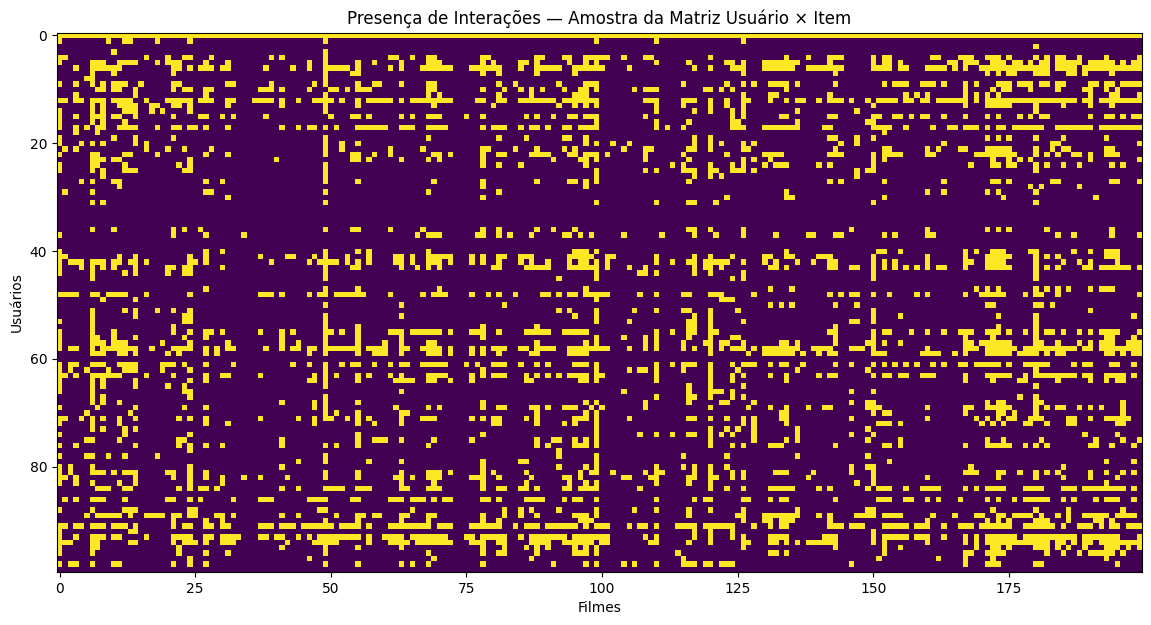

In [88]:
interaction_matrix = (
    user_item_matrix
    .notna()
    .astype(int)
)

sample = interaction_matrix.iloc[:100, :200]

plt.figure(figsize=(14, 7))

plt.imshow(
    sample,
    aspect="auto",
    interpolation="nearest"
)

plt.title("Presença de Interações — Amostra da Matriz Usuário × Item")
plt.xlabel("Filmes")
plt.ylabel("Usuários")

plt.show()

### 8.4 Sobreposição entre Usuários

Métodos de User-Based Collaborative Filtering procuram identificar usuários com padrões de preferência semelhantes.

Entretanto, a similaridade entre dois usuários depende da existência de itens avaliados em comum.

Em uma matriz esparsa, alguns pares de usuários podem possuir poucas interações compartilhadas, tornando a estimativa de similaridade menos confiável.

In [89]:
interaction_matrix = user_item_matrix.notna().astype(int)

user_overlap = (
    interaction_matrix
    @ interaction_matrix.T
)

user_overlap.head()

user_id,1,2,3,4,5,6,7,8,9,10,...,934,935,936,937,938,939,940,941,942,943
user_id,,,,,,,,,,,,,,,,,,,,,
1,272,18,8,7,80,96,145,34,5,77,...,77,15,48,19,36,15,52,10,27,83
2,18,62,9,7,5,32,18,6,6,16,...,15,14,33,20,24,11,17,7,12,9
3,8,9,54,13,1,10,14,7,2,8,...,3,2,16,6,10,2,15,4,9,2
4,7,7,13,24,2,6,12,8,2,4,...,3,1,8,6,7,1,10,4,8,4
5,80,5,1,2,175,42,102,23,4,35,...,58,6,15,5,21,7,28,6,17,59


In [96]:
overlap_values = user_overlap.values.astype(float)

np.fill_diagonal(
    overlap_values,
    np.nan
)

valid_overlaps = overlap_values[
    ~np.isnan(overlap_values)
]

print(f"Média:   {np.mean(valid_overlaps):.2f}")
print(f"Mediana: {np.median(valid_overlaps):.2f}")
print(f"Máximo:  {np.max(valid_overlaps):.0f}")

zero_overlap = (
    valid_overlaps == 0
).mean()

print(
    f"Pares de usuários sem itens em comum: "
    f"{zero_overlap:.2%}"
)

Média:   18.81
Mediana: 10.00
Máximo:  346
Pares de usuários sem itens em comum: 3.39%


### 8.5 Ausência de Interação × Avaliação Negativa

Uma célula vazia da matriz usuário-item representa uma **interação não observada**.

Isso é diferente de uma avaliação negativa.

Por exemplo, se um usuário não avaliou determinado filme, não é possível concluir que ele não goste do filme. O usuário pode simplesmente nunca tê-lo assistido ou avaliado.

Portanto, valores ausentes na matriz não devem ser interpretados diretamente como ratings iguais a zero.

### 8.6 Implicações para Collaborative Filtering

A análise da matriz usuário-item evidencia alguns dos principais desafios enfrentados por métodos de Collaborative Filtering.

A elevada esparsidade significa que a maior parte das combinações entre usuários e filmes não possui uma interação observada.

Em abordagens baseadas em vizinhança, como User-Based Collaborative Filtering, isso pode resultar em poucos itens avaliados em comum entre determinados pares de usuários, reduzindo a confiabilidade das medidas de similaridade.

De forma semelhante, itens com poucas avaliações possuem menos informação disponível para abordagens Item-Based.

Essas características motivam tanto o uso de critérios mínimos de sobreposição em métodos baseados em similaridade quanto abordagens capazes de aprender representações latentes de usuários e itens, como Matrix Factorization.

### 8.7 Principais Observações

A análise da matriz usuário-item evidencia características fundamentais do problema de recomendação:

- existem aproximadamente 1,59 milhão de combinações possíveis entre usuários e filmes;
- apenas 100 mil dessas combinações possuem avaliações observadas;
- a matriz apresenta aproximadamente **93,7% de esparsidade**;
- a ausência de uma interação não representa uma avaliação negativa;
- a esparsidade reduz a quantidade de informação compartilhada entre determinados pares de usuários e itens;
- medidas de similaridade podem se tornar menos confiáveis quando calculadas sobre poucas interações em comum;
- essas características representam desafios importantes para abordagens baseadas em vizinhança;
- modelos de fatores latentes representam uma alternativa para aprender representações mais compactas de usuários e itens.

## 9. Análise Temporal

### 9.1 Distribuição Temporal das Interações

Além do volume de avaliações em cada período, é importante compreender como as interações estão distribuídas ao longo da janela temporal disponível.

A distribuição acumulada permite identificar em que momento diferentes proporções das interações já haviam ocorrido, fornecendo uma visão útil para a definição posterior das estratégias de treino e teste.

In [97]:
ratings_sorted = ratings.sort_values(
    "datetime"
).copy()

ratings_sorted["cumulative_percentage"] = (
    range(1, len(ratings_sorted) + 1)
)

ratings_sorted["cumulative_percentage"] = (
    ratings_sorted["cumulative_percentage"]
    / len(ratings_sorted)
    * 100
)

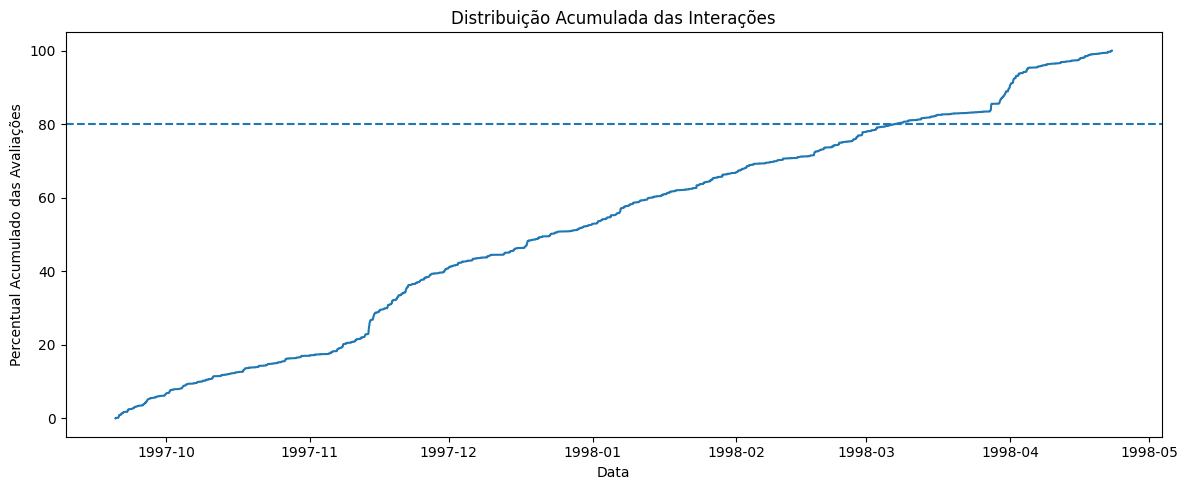

In [98]:
plt.figure(figsize=(12, 5))

plt.plot(
    ratings_sorted["datetime"],
    ratings_sorted["cumulative_percentage"]
)

plt.title("Distribuição Acumulada das Interações")
plt.xlabel("Data")
plt.ylabel("Percentual Acumulado das Avaliações")

plt.axhline(
    y=80,
    linestyle="--"
)

plt.tight_layout()
plt.show()

In [99]:
cutoff_80 = ratings_sorted.iloc[
    int(len(ratings_sorted) * 0.8) - 1
]["datetime"]

print(
    f"Data correspondente a aproximadamente 80% "
    f"das interações: {cutoff_80}"
)

Data correspondente a aproximadamente 80% das interações: 1998-03-07 02:21:09


### 9.2 Histórico Temporal dos Usuários

Os usuários podem apresentar históricos de interação em períodos diferentes.

Para avaliar essa característica, serão identificadas a primeira e a última interação registrada para cada usuário, permitindo analisar a extensão temporal de seus históricos.

In [100]:
user_temporal_stats = (
    ratings
    .groupby("user_id")
    .agg(
        first_interaction=("datetime", "min"),
        last_interaction=("datetime", "max"),
        n_ratings=("rating", "size")
    )
)

user_temporal_stats["history_days"] = (
    user_temporal_stats["last_interaction"]
    - user_temporal_stats["first_interaction"]
).dt.total_seconds() / 86400

user_temporal_stats.head()

,first_interaction,last_interaction,n_ratings,history_days
user_id,,,,
1,1997-09-22 21:57:58,1998-03-13 01:15:36,272,171.137245
2,1998-02-27 03:26:00,1998-03-04 02:57:20,62,4.980093
3,1998-03-07 02:15:39,1998-03-07 02:24:42,54,0.006285
4,1998-04-08 02:09:34,1998-04-08 03:02:00,24,0.036412
5,1997-09-30 15:57:44,1997-11-10 21:54:58,175,41.248079


In [101]:
user_temporal_stats["history_days"].describe()

,history_days
count,943.000000
mean,23.356952
std,50.802358
min,0.001389
25%,0.012234
50%,0.034271
75%,8.563623
max,212.529907


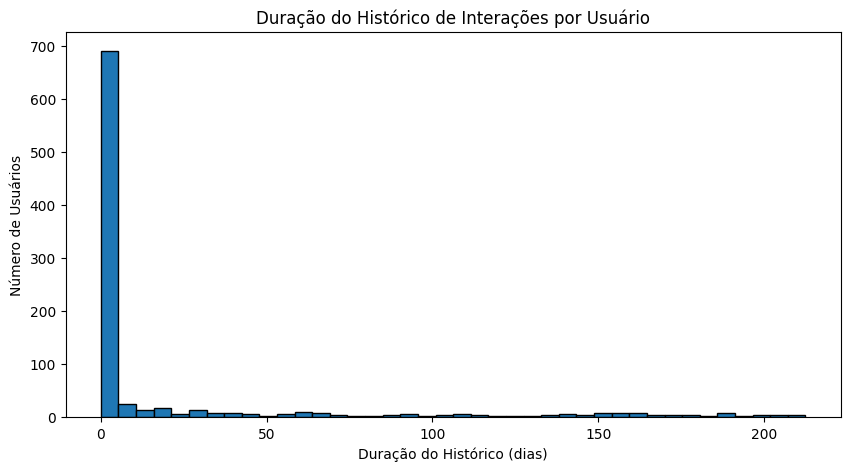

In [102]:
plt.figure(figsize=(10, 5))

plt.hist(
    user_temporal_stats["history_days"],
    bins=40,
    edgecolor="black"
)

plt.title("Duração do Histórico de Interações por Usuário")
plt.xlabel("Duração do Histórico (dias)")
plt.ylabel("Número de Usuários")

plt.show()

### 9.3 Recência das Interações

A distância temporal entre interações consecutivas ajuda a caracterizar a dinâmica do comportamento dos usuários.

Em aplicações reais, a recência pode ser relevante porque preferências recentes podem representar melhor o interesse atual do usuário do que interações realizadas há muito tempo.

In [105]:
user_timeline = ratings.sort_values(
    ["user_id", "datetime"]
).copy()

user_timeline["time_since_previous"] = (
    user_timeline
    .groupby("user_id")["datetime"]
    .diff()
)

user_timeline["hours_since_previous"] = (
    user_timeline["time_since_previous"]
    .dt.total_seconds()
    / 3600
)

user_timeline[
    "hours_since_previous"
].describe()

,hours_since_previous
count,99057.000000
mean,5.336468
std,80.171325
min,0.000000
25%,0.000000
50%,0.000000
75%,0.010278
max,4858.391667


Há uma peculiaridade do MovieLens percebida nos resultados: vários usuários registraram muitas avaliações em períodos relativamente curtos.

Por isso, não devemos automaticamente interpretar cada timestamp como o momento em que o filme foi assistido. Ele representa o momento em que a avaliação foi registrada.

### 9.4 Split Aleatório × Split Temporal

A estratégia utilizada para separar os dados de treino e teste possui impacto direto na avaliação de um sistema de recomendação.

Uma abordagem simples consiste em selecionar aleatoriamente parte das interações para teste. Entretanto, essa estratégia pode permitir que o modelo utilize interações futuras de um usuário para tentar prever interações ocorridas anteriormente.

Considerando a natureza temporal das interações, os experimentos posteriores utilizarão uma separação que respeite a ordem cronológica do histórico dos usuários.

Essa estratégia busca aproximar a avaliação offline do cenário real de recomendação: utilizar informações conhecidas no passado para recomendar itens que se tornariam relevantes posteriormente.

A definição exata do protocolo de treino, validação e teste será realizada na etapa de modelagem, considerando também os requisitos específicos de cada algoritmo e das métricas Top-N.

### 9.5 Cold Start e Avaliação Temporal

Uma divisão temporal pode resultar em usuários ou itens presentes no conjunto de teste que não possuem histórico correspondente no conjunto de treino.

Esse fenômeno está relacionado ao problema de **cold start**.

No caso de novos usuários, não existe histórico suficiente para inferir suas preferências por Collaborative Filtering.

No caso de novos itens, ainda não existem interações suficientes para que modelos colaborativos aprendam sua relação com outros itens ou usuários.

Modelos baseados em conteúdo podem ajudar particularmente no problema de novos itens, desde que seus atributos estejam disponíveis.

### 9.6 Principais Observações

A análise temporal evidencia aspectos importantes para a avaliação dos sistemas de recomendação:

- as interações estão distribuídas ao longo do tempo;
- usuários apresentam diferentes períodos e durações de atividade;
- o timestamp representa o momento de registro da avaliação e não necessariamente o momento em que o filme foi consumido;
- splits aleatórios podem utilizar informações futuras para prever interações anteriores;
- uma estratégia temporal representa melhor o cenário de utilização de um recomendador;
- splits temporais podem revelar situações de cold start que seriam parcialmente ocultadas por divisões aleatórias;
- a estratégia de avaliação deverá garantir que os diferentes modelos sejam comparados sob o mesmo protocolo.

## 10. Conclusões da EDA e Implicações para Modelagem



A análise exploratória do MovieLens 100K revelou características importantes para a construção e avaliação dos sistemas de recomendação.

O dataset contém **100.000 avaliações explícitas**, realizadas por **943 usuários** sobre **1.682 filmes**, permitindo analisar o problema a partir das interações entre usuários e itens, dos atributos dos filmes e da dimensão temporal.

Os principais achados foram:

- os ratings não estão distribuídos uniformemente, apresentando maior concentração em avaliações intermediárias e positivas;
- usuários apresentam diferentes níveis de atividade e diferentes padrões na utilização da escala de ratings;
- a quantidade de interações é distribuída de forma desigual entre os filmes, com poucos itens concentrando uma parcela relevante das avaliações;
- a distribuição de popularidade apresenta comportamento de **long tail**;
- os gêneros fornecem uma representação simples do conteúdo dos filmes e permitem identificar diferenças entre os perfis de preferência dos usuários;
- a matriz usuário-item apresenta aproximadamente **93,7% de esparsidade**, característica que representa um desafio importante para métodos baseados em Collaborative Filtering;
- a quantidade de itens avaliados em comum varia entre pares de usuários, podendo afetar a confiabilidade das medidas de similaridade;
- as interações possuem uma dimensão temporal que deve ser considerada na estratégia de avaliação dos modelos.

### 10.2 Achados e Decisões de Modelagem

Os resultados da análise exploratória possuem implicações diretas sobre as abordagens que serão utilizadas nas próximas etapas.

| Achado da EDA | Implicação | Estratégia |
|---|---|---|
| Concentração das interações em poucos filmes | Um recomendador simples pode obter resultados razoáveis favorecendo itens populares | Criar um **Popularity Baseline** |
| Diferentes padrões individuais de rating | O mesmo rating pode representar níveis diferentes de preferência entre usuários | Avaliar centralização/normalização dos ratings |
| Informações de gênero disponíveis | É possível representar filmes e preferências por características de conteúdo | Implementar **Content-Based Filtering** |
| Interações compartilhadas entre usuários e itens | Permitem calcular similaridades colaborativas | Implementar **User-Based e Item-Based Collaborative Filtering** |
| Alta esparsidade da matriz usuário-item | Similaridades podem ser pouco confiáveis e grande parte da matriz não é observada | Avaliar **Matrix Factorization** |
| Long tail de popularidade | Modelos podem favorecer excessivamente itens populares | Avaliar cobertura, diversidade e viés de popularidade |
| Dimensão temporal das interações | Splits aleatórios podem gerar avaliações pouco realistas | Utilizar **split temporal** |
| Possibilidade de novos usuários ou itens | Collaborative Filtering depende de histórico | Investigar estratégias para **cold start** |

### 10.3 Estratégia de Modelagem

Com base nas características identificadas durante a análise exploratória, os modelos serão desenvolvidos de forma incremental, partindo de estratégias simples até abordagens capazes de capturar padrões mais complexos de preferência.

A sequência inicial de experimentos será:

1. **Popularity Baseline**
   - recomendação baseada na popularidade global dos filmes;
   - estabelecimento de uma referência mínima de desempenho.

2. **Content-Based Filtering**
   - representação dos filmes por seus gêneros;
   - construção de perfis de preferência dos usuários;
   - recomendação baseada na similaridade entre usuários e conteúdo.

3. **Neighborhood-Based Collaborative Filtering**
   - User-Based Collaborative Filtering;
   - Item-Based Collaborative Filtering;
   - comparação de diferentes medidas de similaridade.

4. **Matrix Factorization**
   - aprendizado de representações latentes de usuários e itens;
   - comparação com os métodos baseados em vizinhança.

5. **Modelo Híbrido**
   - combinação de informações colaborativas e de conteúdo;
   - análise de possíveis benefícios em situações com menor quantidade de interações.

### 10.4 Estratégia de Avaliação

O objetivo principal do sistema será gerar listas personalizadas de recomendações (**Top-N Recommendation**).

Por esse motivo, a avaliação não será limitada à capacidade de prever exatamente os valores dos ratings.

Os modelos serão comparados principalmente por métricas relacionadas à qualidade do ranking das recomendações, incluindo:

- **Precision@K**;
- **Recall@K**;
- **NDCG@K**.

Também serão consideradas métricas complementares relacionadas ao comportamento global do sistema, como:

- **Catalog Coverage**;
- diversidade;
- novidade;
- viés de popularidade.

Quando aplicável, métricas de previsão de ratings, como **MAE** e **RMSE**, poderão ser utilizadas como medidas auxiliares.

A separação entre treino e teste respeitará a ordem temporal das interações, buscando aproximar a avaliação offline de um cenário real de recomendação.

### 10.5 Limitações do Dataset

Embora o MovieLens 100K seja adequado para experimentação e comparação de algoritmos de recomendação, algumas limitações devem ser consideradas.

O dataset contém apenas usuários que realizaram pelo menos 20 avaliações. Consequentemente, o problema de cold start de novos usuários é menos representado do que seria esperado em um sistema real.

Além disso, o conjunto contém predominantemente feedback explícito na forma de ratings. Em aplicações reais, sistemas de recomendação frequentemente utilizam feedback implícito, como visualizações, cliques, compras, tempo de consumo ou outras formas de interação.

Os atributos disponíveis sobre os itens também são relativamente simples, sendo os gêneros a principal informação de conteúdo utilizada neste projeto.

Por fim, o timestamp representa o momento em que a avaliação foi registrada e não necessariamente o momento em que o filme foi consumido.

Essas limitações serão consideradas na interpretação dos resultados e na definição de experimentos posteriores.

### 10.6 Próximos Passos

Com a análise exploratória concluída, a próxima etapa consiste na construção de um pipeline de avaliação comum aos diferentes sistemas de recomendação.

Inicialmente será definido o protocolo de separação temporal entre treino e teste e as funções utilizadas para calcular as métricas Top-N.

Em seguida, será implementado um **Popularity Baseline**, que servirá como referência para avaliar se os modelos personalizados efetivamente adicionam valor em relação a uma estratégia simples baseada na popularidade dos itens.

A partir desse baseline serão implementadas e comparadas progressivamente abordagens Content-Based, Collaborative Filtering e Matrix Factorization.